In [1]:
import json
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

Matplotlib is building the font cache; this may take a moment.
/Users/godblessjames/dev/medqa-finetune/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load tokenizer for input length analysis
model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Train Data Validation

In [3]:
data_path = "../data/train.jsonl"
token_counts = []

In [4]:
# Load preppared data
with open(data_path, "r") as f:
    for line in f:
        item = json.loads(line)
        # Combine all messages into one string to simulate the full context
        full_text = ""
        for msg in item["messages"]:
            full_text += f"<|im_start|>{msg['role']}\n{msg['content']}<|im_end|>\n"
        
        tokens = tokenizer.encode(full_text)
        token_counts.append(len(tokens))

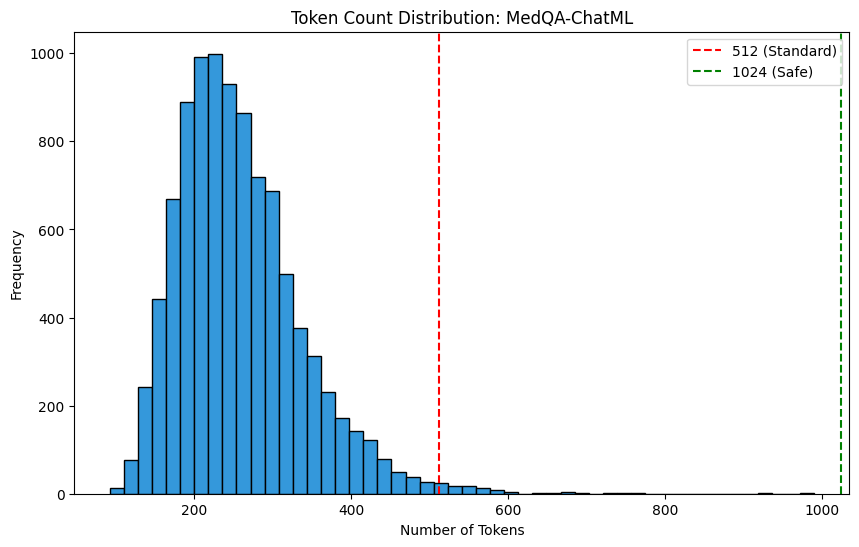

In [5]:
# Plotting the token count distribution
plt.figure(figsize=(10, 6))
plt.hist(token_counts, bins=50, color='#3498db', edgecolor='black')
plt.title("Token Count Distribution: MedQA-ChatML")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.axvline(x=512, color='r', linestyle='--', label='512 (Standard)')
plt.axvline(x=1024, color='g', linestyle='--', label='1024 (Safe)')
plt.legend()
plt.show()

In [6]:
print(f"Max Tokens: {max(token_counts)}")
print(f"Mean Tokens: {sum(token_counts)/len(token_counts):.2f}")
print(f"99th Percentile: {sorted(token_counts)[int(len(token_counts)*0.99)]}")

Max Tokens: 990
Mean Tokens: 257.65
99th Percentile: 506


# Test Data Validation

In [10]:
# test data
test_data_path = "../data/test.jsonl"
test_token_counts = []

In [11]:
# Load preppared data
with open(test_data_path, "r") as f:
    for line in f:
        item = json.loads(line)
        # Combine all messages into one string to simulate the full context
        full_text = ""
        for msg in item["messages"]:
            full_text += f"<|im_start|>{msg['role']}\n{msg['content']}<|im_end|>\n"
        
        tokens = tokenizer.encode(full_text)
        test_token_counts.append(len(tokens))

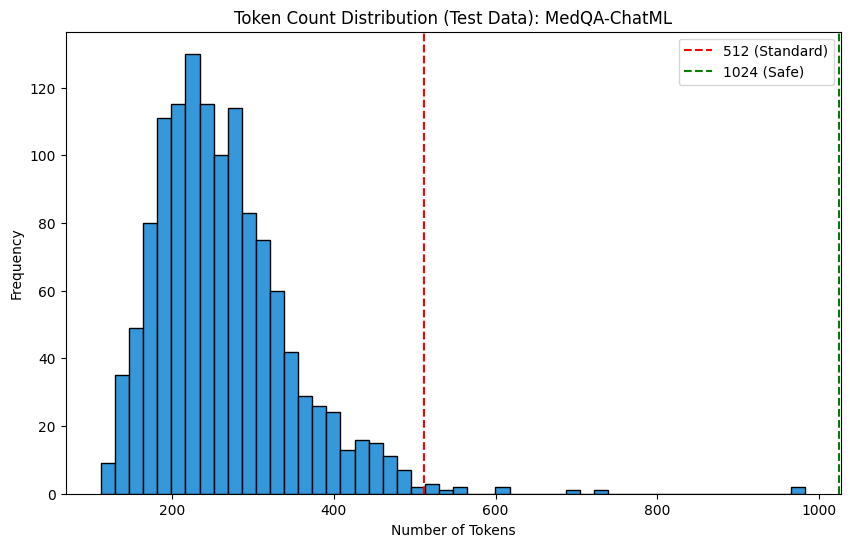

In [13]:
# Plotting the token count distribution for test data
plt.figure(figsize=(10, 6))
plt.hist(test_token_counts, bins=50, color='#3498db', edgecolor='black')
plt.title("Token Count Distribution (Test Data): MedQA-ChatML")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.axvline(x=512, color='r', linestyle='--', label='512 (Standard)')
plt.axvline(x=1024, color='g', linestyle='--', label='1024 (Safe)')
plt.legend()
plt.show()

In [15]:
print(f"Max Tokens: {max(test_token_counts)}")
print(f"Mean Tokens: {sum(test_token_counts)/len(test_token_counts):.2f}")
print(f"99th Percentile: {sorted(test_token_counts)[int(len(test_token_counts)*0.99)]}")

Max Tokens: 983
Mean Tokens: 264.30
99th Percentile: 511
